# Face Recognition

я убрал введение что бы на кагл загрузить, там ограничения в 1mb

## Task 1 (5 points): build a neural network for faces classification as discribed above.

### Dataset

We will train out face recognition network on part of the [CelebA dataset](https://mmlab.ie.cuhk.edu.hk/projects/CelebA.html). But we'll use a version of it that has all the images in it aligned and cropped. You can download the dataset using this link: https://disk.yandex.ru/d/S8f03spLIA1wrw or using the code below:

In [2]:
! pip install wldhx.yadisk-direct
! curl -L $(yadisk-direct https://disk.yandex.ru/d/S8f03spLIA1wrw) -o celebA_train.zip
! unzip -qq celebA_train.zip

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  162M  100  162M    0     0  10.6M      0  0:00:15  0:00:15 --:--:-- 24.1M


Let's look at the data first:

In [3]:
! ls celebA_train_500/

celebA_anno.txt  celebA_imgs  celebA_train_split.txt


- celebA_imgs — folder with aligned images
- celebA_anno.txt — file with annotations: which person each image corresponds to
- celebA_train_split.txt — file with train/val/test info

In [5]:
import os
import cv2
import numpy as np
from PIL import Image
from skimage import io, transform
import torchvision.models as models
import wandb
from tqdm import tqdm

import torch
from torch import nn
import torchvision.transforms as transforms
from torch.utils.data import Dataset

import matplotlib.pyplot as plt

Let's visualize some images to understand what we're dealing with:

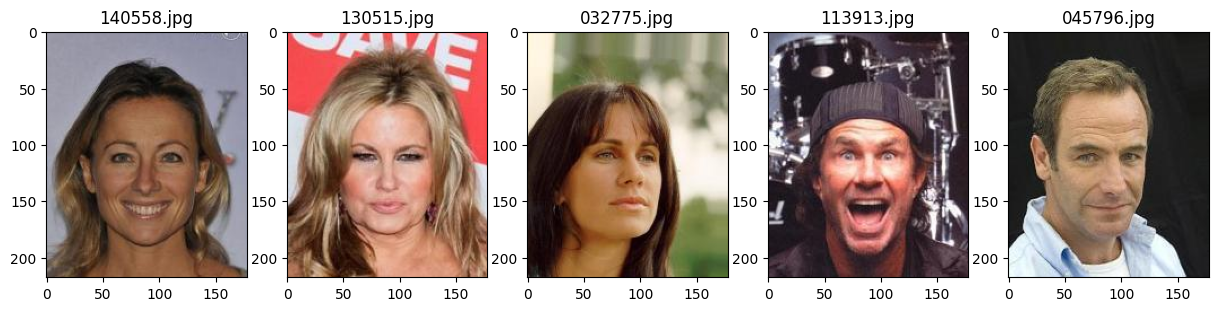

In [5]:
def show_imgs(images_names):
    imgs = []
    for img in images_names:
      img = Image.open(os.path.join('celebA_train_500/celebA_imgs/', img))
      imgs.append(np.array(img))

    f, axes= plt.subplots(1, len(imgs), figsize=(3*len(imgs),5))
    for i, axis in enumerate(axes):
        axes[i].imshow(imgs[i], cmap='gray')
        axes[i].set_title(images_names[i])
    plt.show()

images_names = os.listdir('./celebA_train_500/celebA_imgs/')[:5]
show_imgs(images_names)


### Train Neural Network

Let's build a Datasets and network using this images:

In [6]:
def get_paths(dataset_type='train'):
    '''
    a function that returnes list of images paths for a given type of the dataset
    params:
      dataset_type: one of 'train', 'val', 'test'
    '''

    labels_dict = {
        'train': 0,
        'val': 1,
        'test': 2,
    }

    f = open('celebA_train_500/celebA_train_split.txt', 'r')
    lines = f.readlines()
    f.close()

    lines = [x.strip().split() for x in lines]
    lines = [x[0] for x in lines if int(x[1]) == labels_dict[dataset_type]]

    images_paths = []
    for filename in lines:
        images_paths.append(os.path.join('celebA_train_500/celebA_imgs/', filename))

    return np.array(images_paths)


class CelebADataset(Dataset):
    """Feel free to rewrite it. For ex. cache all images in RAM to increase training speed"""
    def __init__(self, dataset_type, transform, aug=None,):
        self.images = get_paths(dataset_type=dataset_type)

        f = open('celebA_train_500/celebA_anno.txt', 'r')
        labels = f.readlines()
        f.close()
        labels = [x.strip().split() for x in labels]
        labels = {x:y for x, y in labels}
        self.labels = [int(labels[x.split('/')[-1]]) for x in self.images]

        self.transform = transform
        self.aug = aug

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]
        label = self.labels[idx]

        image = Image.open(img_name)

        if self.aug:
            sample = self.aug(
                image=image,
            )
        else:
            sample = {
                'image': image,
                'label': label,
            }

        sample['image'] = self.transform(sample['image'])

        return sample

In [7]:
from torch.utils.data import DataLoader, Dataset

train_transform = transforms.Compose([
    transforms.Resize(200),
    transforms.RandomCrop(160),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(4),
    transforms.RandomAffine(0, translate=(0.03, 0.03)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1, hue=0.03),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
])

val_transform = transforms.Compose([
    transforms.Resize(200),
    transforms.CenterCrop(160),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
])

train_data = CelebADataset('train', train_transform)
val_data = CelebADataset('val', val_transform)
test_data = CelebADataset('test', val_transform)

batch_size = 128
num_workers = 4 if torch.cuda.is_available() else 0

train_loader = DataLoader(
    train_data, 
    batch_size=batch_size, 
    shuffle=True,
    num_workers=num_workers,
    pin_memory=True,
    persistent_workers=True if num_workers > 0 else False
)

val_loader = DataLoader(
    val_data, 
    batch_size=batch_size, 
    shuffle=False,
    num_workers=num_workers,
    pin_memory=True,
    persistent_workers=True if num_workers > 0 else False
)

test_loader = DataLoader(
    test_data, 
    batch_size=batch_size, 
    shuffle=False,
    num_workers=num_workers,
    pin_memory=True,
    persistent_workers=True if num_workers > 0 else False
)

**Workflow**: train a model on train_data using val_data for validation. Use standard CE loss. Calculate the loss and accuracy on test set after training. Don't forget to log parameters, loss and metrics to Weights&biases e.g.

You may use whatever model you want, including pre-trained on ImageNet models from torchvision. Please note, that **it is not allowed to use pre-trained models on any other dataset except ImageNet**.

To get higher score, try to adjust hyperparameters, maybe try augmentations, etc.

Hints: Do not use too big model. Small ResNet-like network is enough to get the required score. Use at least 2 linear layers on the bottom. You'll need to drop the last layer after training and get image embeddings from the pre-last layer. It's not required to get the embedding from linear layer though: you may get it from last convolution layer, if you want.

**To get the first half of the mark for this section you need to achieve 70% accuracy on test set**.

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [18]:
class FaceRecognitionModel(nn.Module):
    def __init__(self, num_classes):
        super(FaceRecognitionModel, self).__init__()
        self.backbone = models.resnet18(pretrained=True)
        for name, param in self.backbone.named_parameters():
            if "layer3" not in name and "layer4" not in name and "fc" not in name:
                param.requires_grad = False

        num_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Sequential(
            nn.Linear(num_features, 512),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        return self.backbone(x)

    def get_embedding(self, x):
        x = self.backbone.conv1(x)
        x = self.backbone.bn1(x)
        x = self.backbone.relu(x)
        x = self.backbone.maxpool(x)
        x = self.backbone.layer1(x)
        x = self.backbone.layer2(x)
        x = self.backbone.layer3(x)
        x = self.backbone.layer4(x)
        x = self.backbone.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.backbone.fc[0](x)
        x = self.backbone.fc[1](x)
        return nn.functional.normalize(x, p=2, dim=1)

In [22]:
num_classes = len(set(train_data.labels))
model = FaceRecognitionModel(num_classes=num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.01,
    momentum=0.9,
    weight_decay=1e-4
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',
    factor=0.5,
    patience=2,
)

wandb.init(project="celeba-face-recognition4", name="resnet18-4", reinit=True)
wandb.config = {
    "batch_size": batch_size,
    "epochs": 39,
    "learning_rate": 0.01,
    "model": "ResNet18"
}

In [25]:
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs=40):
    best_val_acc = 0.0
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        running_corrects = 0
        progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")
        for batch in progress_bar:
            inputs = batch['image'].to(device)
            labels = batch['label'].to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)
            progress_bar.set_postfix(loss=f"{loss.item():.4f}")

        epoch_loss = running_loss / len(train_loader.dataset)
        epoch_acc = running_corrects.double() / len(train_loader.dataset)
        history['train_loss'].append(epoch_loss)
        history['train_acc'].append(epoch_acc)
        model.eval()
        val_loss = 0.0
        val_corrects = 0

        with torch.no_grad():
            for batch in val_loader:
                inputs = batch['image'].to(device)
                labels = batch['label'].to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                _, preds = torch.max(outputs, 1)

                val_loss += loss.item() * inputs.size(0)
                val_corrects += torch.sum(preds == labels.data)

        val_loss = val_loss / len(val_loader.dataset)
        val_acc = val_corrects.double() / len(val_loader.dataset)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        scheduler.step(val_acc)

        print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

        wandb.log({
            'epoch': epoch,
            'train_loss': epoch_loss,
            'train_acc': epoch_acc,
            'val_loss': val_loss,
            'val_acc': val_acc,
            'lr': optimizer.param_groups[0]['lr']
        })

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), 'best_face_model.pth')
            wandb.save('best_face_model.pth')

    return model, history, best_val_acc

In [26]:
model, history, best_val_acc = train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    scheduler,
    num_epochs=39
)

Epoch 1/39: 100%|██████████| 67/67 [00:17<00:00,  3.82it/s, loss=6.1170]


Epoch 1/39 | Train Loss: 6.1724 Acc: 0.0060 | Val Loss: 5.9431 Acc: 0.0229


Epoch 2/39: 100%|██████████| 67/67 [00:17<00:00,  3.79it/s, loss=5.1996]


Epoch 2/39 | Train Loss: 5.6306 Acc: 0.0288 | Val Loss: 5.0790 Acc: 0.0602


Epoch 3/39: 100%|██████████| 67/67 [00:17<00:00,  3.82it/s, loss=4.5273]


...

Epoch 37/39 | Train Loss: 0.0280 Acc: 0.9964 | Val Loss: 1.4035 Acc: 0.7093


Epoch 38/39: 100%|██████████| 67/67 [00:17<00:00,  3.81it/s, loss=0.0215]


Epoch 38/39 | Train Loss: 0.0251 Acc: 0.9980 | Val Loss: 1.3926 Acc: 0.7109


Epoch 39/39: 100%|██████████| 67/67 [00:17<00:00,  3.84it/s, loss=0.0169]


Epoch 39/39 | Train Loss: 0.0223 Acc: 0.9980 | Val Loss: 1.3907 Acc: 0.7093


In [32]:
model.load_state_dict(torch.load('best_face_model.pth'))
model = model.to(device)
model.eval()
print(f"{best_val_acc:.4f}")

0.7109


Code for model evaluating (you can modify it if you want):

In [33]:
def evaluate(model, dataloader, loss_fn):

    losses = []

    num_correct = 0
    num_elements = 0

    for i, batch in enumerate(dataloader):

        X_batch, y_batch = batch['image'], batch['label']
        num_elements += len(y_batch)

        with torch.no_grad():
            logits = model(X_batch.to(device))

            loss = loss_fn(logits, y_batch.to(device))
            losses.append(loss.item())

            y_pred = torch.argmax(logits, dim=1)

            num_correct += torch.sum(y_pred.cpu() == y_batch)

    accuracy = num_correct / num_elements

    return accuracy.numpy(), np.mean(losses)

In [34]:
test_accuracy, test_loss = evaluate(model, test_loader, nn.CrossEntropyLoss())
test_accuracy, test_loss

(array(0.71428573, dtype=float32), np.float64(1.452577645962055))

**Cosine similarity calculation**: drop the last layer of trained network. Get embeddings for some images from train set and for images from test set. Calculate cosine similarities between embeddings corresponding to the pictures of the same person and different people. Is the difference big in any of cases?

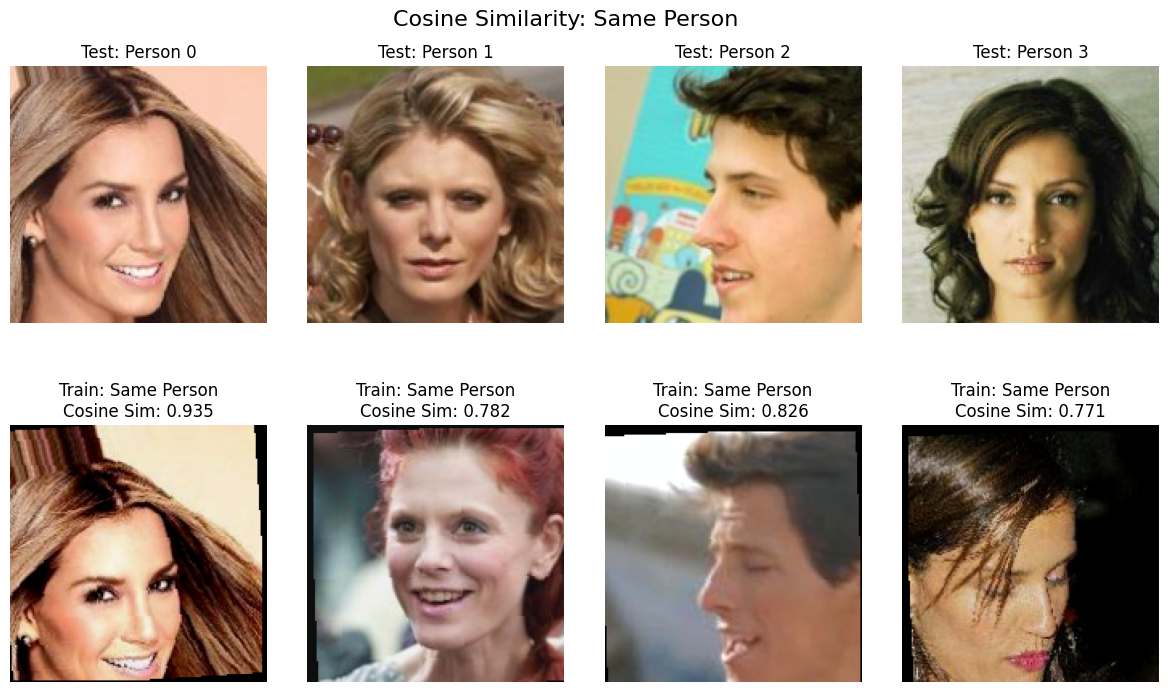

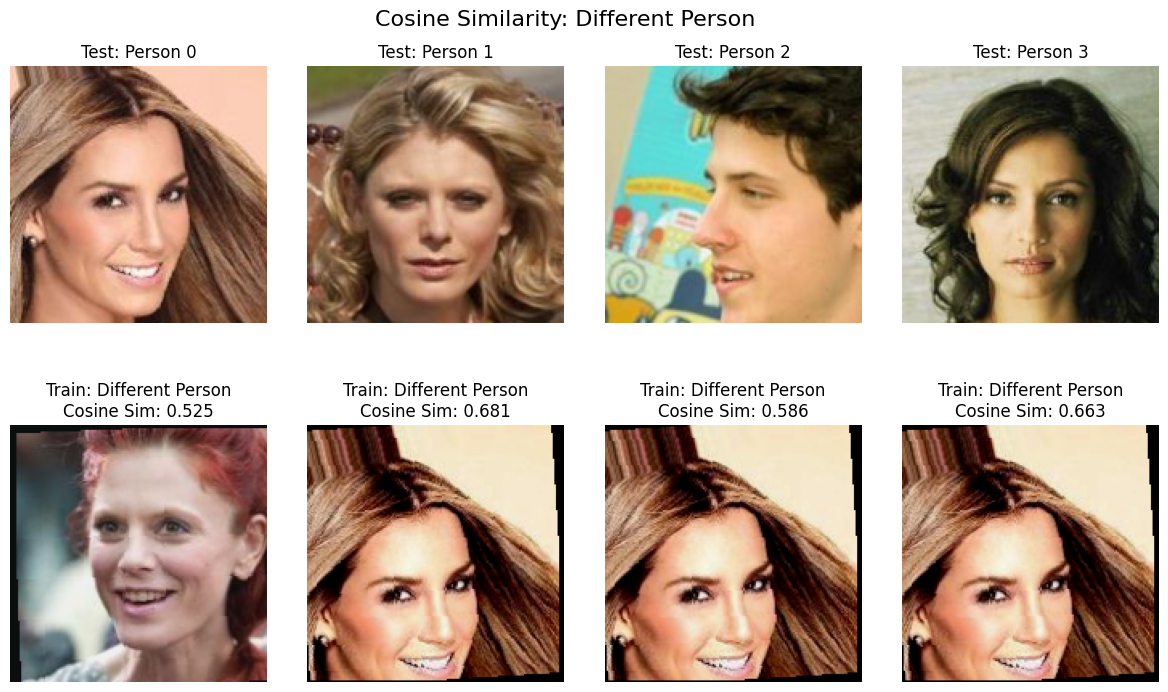

In [45]:
model.eval()

fixed_test_loader = DataLoader(
    test_data, 
    batch_size=64,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

fixed_train_loader = DataLoader(
    train_data, 
    batch_size=64,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

def get_batch_embeddings(loader):
    embeddings = []
    labels = []
    images = []
    
    for batch in loader:
        with torch.no_grad():
            batch_images = batch['image'].to(device)
            batch_labels = batch['label']
            batch_embeddings = model.get_embedding(batch_images)
            embeddings.append(batch_embeddings.cpu())
            labels.append(batch_labels)
            images.append(batch_images.cpu())
        break
    return torch.cat(embeddings), torch.cat(labels), torch.cat(images)

test_embs, test_labels, test_imgs = get_batch_embeddings(fixed_test_loader)
train_embs, train_labels, train_imgs = get_batch_embeddings(fixed_train_loader)
def denormalize(img):
    img = img.permute(1, 2, 0).numpy()
    img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    img = np.clip(img, 0, 1)
    return img

unique_persons = torch.unique(test_labels)[:4]
same_person_examples = []
diff_person_examples = []

for person_id in unique_persons:
    test_indices = torch.where(test_labels == person_id)[0]
    if len(test_indices) == 0:
        continue
    test_idx = test_indices[0].item()
    same_person_idx = torch.where(train_labels == person_id)[0]
    if len(same_person_idx) > 0:
        same_idx = same_person_idx[0].item()
        same_sim = torch.nn.functional.cosine_similarity(
            test_embs[test_idx].unsqueeze(0), 
            train_embs[same_idx].unsqueeze(0)
        ).item()
        same_person_examples.append((test_idx, same_idx, same_sim, person_id.item()))
    diff_person_idx = torch.where(train_labels != person_id)[0]
    if len(diff_person_idx) > 0:
        diff_idx = diff_person_idx[0].item()
        diff_sim = torch.nn.functional.cosine_similarity(
            test_embs[test_idx].unsqueeze(0), 
            train_embs[diff_idx].unsqueeze(0)
        ).item()
        diff_person_examples.append((test_idx, diff_idx, diff_sim, person_id.item()))
plt.figure(figsize=(15, 8))

for i, (test_idx, train_idx, sim, person_id) in enumerate(same_person_examples[:4]):
    plt.subplot(2, 4, i+1)
    plt.imshow(denormalize(test_imgs[test_idx]))
    plt.title(f"Test: Person {person_id}")
    plt.axis('off')
    plt.subplot(2, 4, i+1+4)
    plt.imshow(denormalize(train_imgs[train_idx]))
    plt.title(f"Train: Same Person\nCosine Sim: {sim:.3f}")
    plt.axis('off')

plt.suptitle("Cosine Similarity: Same Person", fontsize=16, y=0.95)
plt.subplots_adjust(hspace=0.4, wspace=0.1)
plt.show()
plt.figure(figsize=(15, 8))

for i, (test_idx, train_idx, sim, person_id) in enumerate(diff_person_examples[:4]):
    plt.subplot(2, 4, i+1)
    plt.imshow(denormalize(test_imgs[test_idx]))
    plt.title(f"Test: Person {person_id}")
    plt.axis('off')
    
    plt.subplot(2, 4, i+1+4)
    plt.imshow(denormalize(train_imgs[train_idx]))
    plt.title(f"Train: Different Person\nCosine Sim: {sim:.3f}")
    plt.axis('off')

plt.suptitle("Cosine Similarity: Different Person", fontsize=16, y=0.95)
plt.subplots_adjust(hspace=0.4, wspace=0.1)
plt.show()

**Cosine similarity distribution**: calculate all the cosine similarities between images in test dataset and train dataset of the same person. This means if you have image of person #106 in test dataset, calculate all similarities between this person's embeddings from test dataset and this person's embeddings from train dataset.

Then also do that for pairs of different people. This means if you have image of person #106 in test dataset, calculate similarities between this person's embeddings from test dataset and other people embeddings from train dataset.

Visualize (build histograms) the cosine similarities distributions for same and different people.

This calculation may take a long time and memory since it's a lot of pairs. You can cut the number of pairs which you calculate distances between. For example, use 1000-5000 examples.

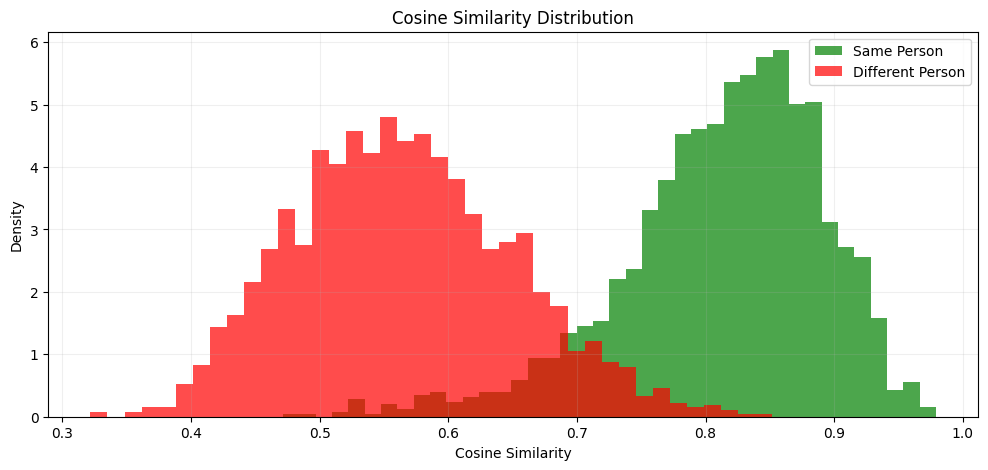

In [50]:
def get_all_embeddings(loader):
    embeddings = []
    labels = []
    for batch in tqdm(loader, desc="Extracting embeddings", leave=False):
        with torch.no_grad():
            images = batch['image'].to(device)
            batch_embs = model.get_embedding(images)
            embeddings.append(batch_embs.cpu())
            labels.append(batch['label'])
    return torch.cat(embeddings), torch.cat(labels)

test_embs, test_labels = get_all_embeddings(DataLoader(test_data, batch_size=64, shuffle=False, num_workers=0))
train_embs, train_labels = get_all_embeddings(DataLoader(train_data, batch_size=64, shuffle=False, num_workers=0))
train_by_class = {}
for emb, label in zip(train_embs, train_labels):
    lbl = label.item()
    if lbl not in train_by_class:
        train_by_class[lbl] = []
    train_by_class[lbl].append(emb)

same_sims = []
diff_sims = []
max_same_pairs = 2000
max_diff_pairs = 2000

for i in range(len(test_embs)):
    if len(same_sims) >= max_same_pairs:
        break
    test_emb = test_embs[i]
    test_label = test_labels[i].item()
    if test_label in train_by_class:
        for train_emb in train_by_class[test_label][:3]:
            sim = torch.nn.functional.cosine_similarity(test_emb.unsqueeze(0), train_emb.unsqueeze(0)).item()
            same_sims.append(sim)
            if len(same_sims) >= max_same_pairs:
                break

for i in range(len(test_embs)):
    if len(diff_sims) >= max_diff_pairs:
        break
    test_emb = test_embs[i]
    test_label = test_labels[i].item()
    
    other_labels = [lbl for lbl in train_by_class.keys() if lbl != test_label]
    np.random.shuffle(other_labels)
    
    for lbl in other_labels[:5]:
        if lbl in train_by_class and train_by_class[lbl]:
            sim = torch.nn.functional.cosine_similarity(
                test_emb.unsqueeze(0), 
                train_by_class[lbl][0].unsqueeze(0)
            ).item()
            diff_sims.append(sim)
            if len(diff_sims) >= max_diff_pairs:
                break

plt.figure(figsize=(12, 5))
plt.hist(same_sims, bins=40, alpha=0.7, label='Same Person', color='green', density=True)
plt.hist(diff_sims, bins=40, alpha=0.7, label='Different Person', color='red', density=True)
plt.title('Cosine Similarity Distribution')
plt.xlabel('Cosine Similarity')
plt.ylabel('Density')
plt.legend()
plt.grid(alpha=0.2)
plt.show()

Now train the same model using ArcFace-loss. You can try to implement it yourself or use [ready-one](https://kevinmusgrave.github.io/pytorch-metric-learning/losses/#arcfaceloss) from pytorch-metric-learning library.

**To get the second half of the mark for this section you need to achieve 70% accuracy on test set**.

In [34]:
!pip install pytorch-metric-learning -q

from pytorch_metric_learning import losses
import torch.optim as optim

In [35]:
class FaceRecognitionModelArcFace(nn.Module):
    def __init__(self, embedding_size=512):
        super(FaceRecognitionModelArcFace, self).__init__()
        self.backbone = models.resnet18(pretrained=True)
        for name, param in self.backbone.named_parameters():
            if "layer3" in name or "layer4" in name:
                param.requires_grad = True
            else:
                param.requires_grad = False
        self.backbone.fc = nn.Identity()
        self.projection = nn.Linear(512, embedding_size)

    def forward(self, x):
        features = self.backbone(x)
        embeddings = self.projection(features)
        return nn.functional.normalize(embeddings, p=2, dim=1)

    def get_embedding(self, x):
        self.eval()
        with torch.no_grad():
            return self.forward(x)

In [36]:
num_classes = len(set(train_data.labels))
embedding_size = 512
model_arcface = FaceRecognitionModelArcFace(embedding_size=embedding_size).to(device)

criterion_arcface = losses.ArcFaceLoss(
    num_classes=num_classes,
    embedding_size=embedding_size,
    margin=0.5,
    scale=64
).to(device)

optimizer = torch.optim.SGD(
    list(model_arcface.parameters()) + list(criterion_arcface.parameters()),
    lr=0.01,
    momentum=0.9,
    weight_decay=2e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
optimizer,
mode='max',
factor=0.5,
patience=3,
)

import wandb
wandb.init(project="celeba-face-recognition", name="resnet18-arcface12", reinit=True)
wandb.config = {
    "batch_size": batch_size,
    "epochs": 45,
    "learning_rate": 0.01,
    "model": "ResNet18-ArcFace",
    "loss": "ArcFaceLoss",
    "embedding_size": embedding_size,
    "margin": 28.6,
    "scale": 64
}


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [31]:
def train_model_arcface(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs=45):
    best_val_acc = 0.0
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        running_corrects = 0
        progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")
        for batch in progress_bar:
            inputs = batch['image'].to(device)
            labels = batch['label'].to(device)
            optimizer.zero_grad()
            embeddings = model(inputs)
            loss = criterion(embeddings, labels)
            
            with torch.no_grad():
                logits = criterion.get_logits(embeddings)
                _, preds = torch.max(logits, 1)
                running_corrects += torch.sum(preds == labels.data)
            
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * inputs.size(0)
            progress_bar.set_postfix(loss=f"{loss.item():.4f}")
        
        epoch_loss = running_loss / len(train_loader.dataset)
        epoch_acc = running_corrects.double() / len(train_loader.dataset)
        history['train_loss'].append(epoch_loss)
        history['train_acc'].append(epoch_acc)
        model.eval()
        val_loss = 0.0
        val_corrects = 0
        
        with torch.no_grad():
            for batch in val_loader:
                inputs = batch['image'].to(device)
                labels = batch['label'].to(device)
                embeddings = model(inputs)
                loss = criterion(embeddings, labels)
                logits = criterion.get_logits(embeddings)
                _, preds = torch.max(logits, 1)
                val_loss += loss.item() * inputs.size(0)
                val_corrects += torch.sum(preds == labels.data)
        
        val_loss = val_loss / len(val_loader.dataset)
        val_acc = val_corrects.double() / len(val_loader.dataset)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        scheduler.step(val_acc)
        
        print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")
        
        wandb.log({
            'epoch': epoch,
            'train_loss': epoch_loss,
            'train_acc': epoch_acc,
            'val_loss': val_loss,
            'val_acc': val_acc,
            'lr': optimizer.param_groups[0]['lr']
        })
        
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save({
                'model_state_dict': model.state_dict(),
                'arcface_state_dict': criterion.state_dict()
            }, 'best_arcface_model.pth')
            wandb.save('best_arcface_model.pth')
    
    return model, history, best_val_acc

In [13]:
model_arcface, history_arcface, best_val_acc_arcface = train_model_arcface(
    model_arcface,
    train_loader,
    val_loader,
    criterion_arcface,
    optimizer,
    scheduler,
    num_epochs=51
)

Epoch 1/51: 100%|██████████| 67/67 [00:19<00:00,  3.43it/s, loss=6.3179]


Epoch 1/51 | Train Loss: 7.1313 Acc: 0.0226 | Val Loss: 5.8894 Acc: 0.0698


Epoch 2/51: 100%|██████████| 67/67 [00:18<00:00,  3.72it/s, loss=4.5449]


Epoch 2/51 | Train Loss: 5.2208 Acc: 0.1433 | Val Loss: 4.6419 Acc: 0.1832


Epoch 3/51: 100%|██████████| 67/67 [00:18<00:00,  3.71it/s, loss=3.6438]


...

Epoch 49/51 | Train Loss: 0.0104 Acc: 0.9987 | Val Loss: 1.8531 Acc: 0.6981


Epoch 50/51: 100%|██████████| 67/67 [00:18<00:00,  3.72it/s, loss=0.0047]


Epoch 50/51 | Train Loss: 0.0092 Acc: 0.9992 | Val Loss: 1.8352 Acc: 0.6976


Epoch 51/51: 100%|██████████| 67/67 [00:18<00:00,  3.67it/s, loss=0.0028]


Epoch 51/51 | Train Loss: 0.0068 Acc: 0.9998 | Val Loss: 1.8354 Acc: 0.6997


In [14]:
checkpoint = torch.load('best_arcface_model.pth')
model_arcface.load_state_dict(checkpoint['model_state_dict'])
criterion_arcface.load_state_dict(checkpoint['arcface_state_dict'])
model_arcface = model_arcface.to(device)
model_arcface.eval()

def evaluate_arcface(model, criterion, dataloader):
    model.eval()
    num_correct = 0
    num_elements = 0
    with torch.no_grad():
        for batch in dataloader:
            images = batch['image'].to(device)
            labels = batch['label'].to(device)
            embeddings = model(images)
            if hasattr(criterion, 'get_logits'):
                logits = criterion.get_logits(embeddings)
            else:
                logits = embeddings @ criterion.W.t() * criterion.scale
            _, preds = torch.max(logits, 1)
            num_correct += torch.sum(preds == labels.data)
            num_elements += labels.size(0)
    accuracy = num_correct.double() / num_elements
    return accuracy.item()

test_accuracy_arcface = evaluate_arcface(model_arcface, criterion_arcface, test_loader)
print(f"test accuracy: {test_accuracy_arcface:.4f}")

test accuracy: 0.7093


ГООООООООЛ 
ПОБЕДА 0.7

Analyze cosine similarity for this model too.

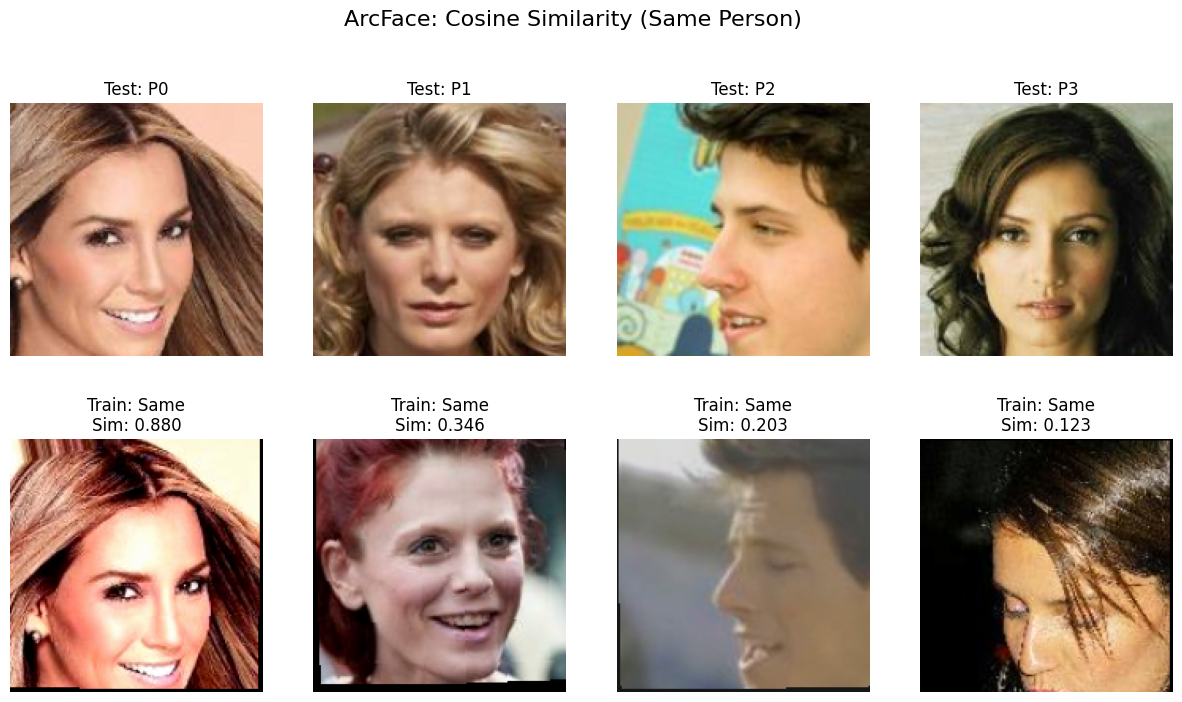

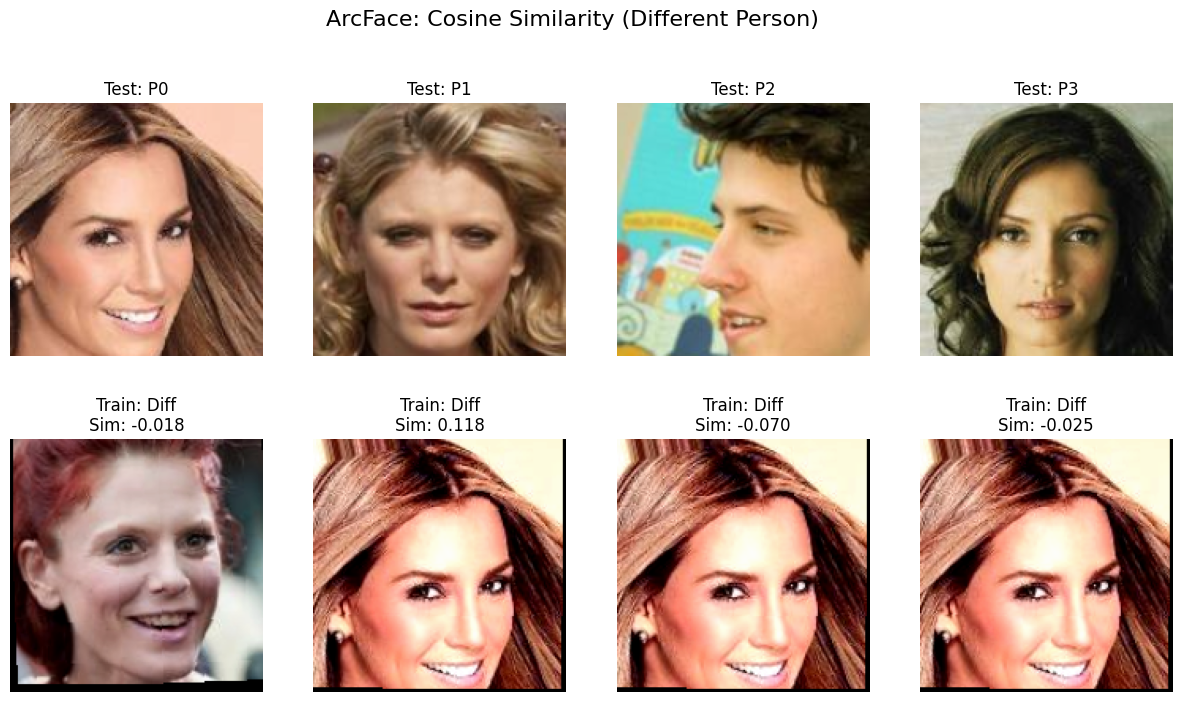

In [17]:
model_arcface.eval()

fixed_test_loader = DataLoader(test_data, batch_size=64, shuffle=False)
fixed_train_loader = DataLoader(train_data, batch_size=64, shuffle=False)

def get_batch_embeddings(loader):
    embeddings = []
    labels = []
    images = []
    
    for batch in loader:
        with torch.no_grad():
            batch_images = batch['image'].to(device)
            batch_labels = batch['label']
            batch_embeddings = model_arcface.get_embedding(batch_images)
            embeddings.append(batch_embeddings.cpu())
            labels.append(batch_labels)
            images.append(batch_images.cpu())
        break
    return torch.cat(embeddings), torch.cat(labels), torch.cat(images)

test_embs, test_labels, test_imgs = get_batch_embeddings(fixed_test_loader)
train_embs, train_labels, train_imgs = get_batch_embeddings(fixed_train_loader)

def denormalize(img):
    img = img.permute(1, 2, 0).numpy()
    img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    img = np.clip(img, 0, 1)
    return img

unique_persons = torch.unique(test_labels)[:4]
same_person_examples = []
diff_person_examples = []

for person_id in unique_persons:
    test_indices = torch.where(test_labels == person_id)[0]
    if len(test_indices) == 0: continue
    test_idx = test_indices[0].item()
    same_person_idx = torch.where(train_labels == person_id)[0]
    if len(same_person_idx) > 0:
        same_idx = same_person_idx[0].item()
        sim = torch.nn.functional.cosine_similarity(
            test_embs[test_idx].unsqueeze(0), 
            train_embs[same_idx].unsqueeze(0)
        ).item()
        same_person_examples.append((test_idx, same_idx, sim, person_id.item()))
    diff_person_idx = torch.where(train_labels != person_id)[0]
    if len(diff_person_idx) > 0:
        diff_idx = diff_person_idx[0].item()
        sim = torch.nn.functional.cosine_similarity(
            test_embs[test_idx].unsqueeze(0), 
            train_embs[diff_idx].unsqueeze(0)
        ).item()
        diff_person_examples.append((test_idx, diff_idx, sim, person_id.item()))

plt.figure(figsize=(15, 8))
for i, (test_idx, train_idx, sim, person_id) in enumerate(same_person_examples[:4]):
    plt.subplot(2, 4, i+1); plt.imshow(denormalize(test_imgs[test_idx])); plt.title(f"Test: P{person_id}"); plt.axis('off')
    plt.subplot(2, 4, i+5); plt.imshow(denormalize(train_imgs[train_idx])); plt.title(f"Train: Same\nSim: {sim:.3f}"); plt.axis('off')
plt.suptitle("ArcFace: Cosine Similarity (Same Person)", fontsize=16)
plt.show()

plt.figure(figsize=(15, 8))
for i, (test_idx, train_idx, sim, person_id) in enumerate(diff_person_examples[:4]):
    plt.subplot(2, 4, i+1); plt.imshow(denormalize(test_imgs[test_idx])); plt.title(f"Test: P{person_id}"); plt.axis('off')
    plt.subplot(2, 4, i+5); plt.imshow(denormalize(train_imgs[train_idx])); plt.title(f"Train: Diff\nSim: {sim:.3f}"); plt.axis('off')
plt.suptitle("ArcFace: Cosine Similarity (Different Person)", fontsize=16)
plt.show()

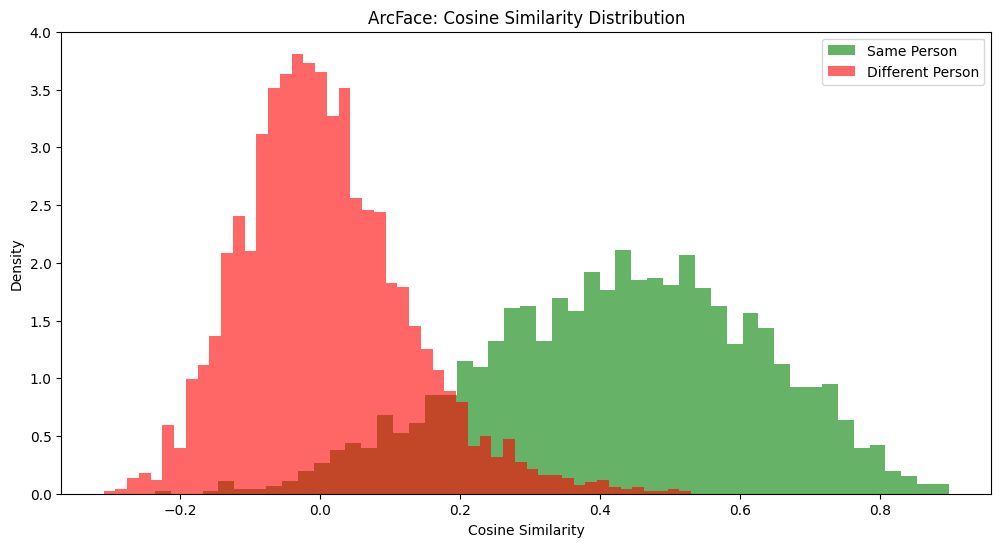

In [20]:
def get_all_embeddings(loader):
    embeddings = []
    labels = []
    model_arcface.eval()
    for batch in tqdm(loader, desc="Extracting embeddings", leave=False):
        with torch.no_grad():
            images = batch['image'].to(device)
            batch_embs = model_arcface.get_embedding(images)
            embeddings.append(batch_embs.cpu())
            labels.append(batch['label'])
    return torch.cat(embeddings), torch.cat(labels)

test_embs, test_labels = get_all_embeddings(DataLoader(test_data, batch_size=64, shuffle=False))
train_embs, train_labels = get_all_embeddings(DataLoader(train_data, batch_size=64, shuffle=False))
train_by_class = {}
for emb, label in zip(train_embs, train_labels):
    lbl = label.item()
    if lbl not in train_by_class: train_by_class[lbl] = []
    train_by_class[lbl].append(emb)

same_sims = []
diff_sims = []

for i in range(min(len(test_embs), 1000)):
    test_emb = test_embs[i]
    test_label = test_labels[i].item()
    if test_label in train_by_class:
        for train_emb in train_by_class[test_label][:2]:
            sim = torch.nn.functional.cosine_similarity(test_emb.unsqueeze(0), train_emb.unsqueeze(0)).item()
            same_sims.append(sim)
    other_labels = [lbl for lbl in train_by_class.keys() if lbl != test_label]
    selected_others = np.random.choice(other_labels, size=3, replace=False)
    for lbl in selected_others:
        train_emb = train_by_class[lbl][0]
        sim = torch.nn.functional.cosine_similarity(test_emb.unsqueeze(0), train_emb.unsqueeze(0)).item()
        diff_sims.append(sim)

plt.figure(figsize=(12, 6))
plt.hist(same_sims, bins=50, alpha=0.6, label='Same Person', color='g', density=True)
plt.hist(diff_sims, bins=50, alpha=0.6, label='Different Person', color='r', density=True)
plt.title('ArcFace: Cosine Similarity Distribution')
plt.xlabel('Cosine Similarity')
plt.ylabel('Density')
plt.legend()
plt.show()

## Bonus task (5 points): Any approach for representation learning

Building a network on task 1 we used an ordinary CE loss and more specific ArcFace loss. But there are many more variants of loss functions that can be used to train neural network and much more schemes for training model. Examples of losses for face recognition and their performance reviews you can find in this paper: https://arxiv.org/pdf/1901.05903.pdf

Now your task is training exactly the same model with exactly the same data using any approach from lecture (if you want to use something different it is better to consult with a teacher). It might be contrastive/triplet/quadruplet loss, any self-supervised pretraining, prototypical network, but not just classification task with different loss.

**To get the whole of the mark for this section you need to achieve at least 70% accuracy on test set and get better results than with CE loss**.
As we don't have a classification layer in our network, we need a custom procedure for accuracy calculation. You can use one of the following procedures:
- calculate accuracy on val and test sets using KNN with embeddings from training set as training points. (easy way)
- compute mean embeddings for every class from training set and use them as reference embeddings.

**Hints**:
- to train model using some losses you'll need to rewrite the Dataset class so it gives you not the random image and its label, but the image, positive/negative images for this image;
- `pytorch-metric-learning` library might be useful too

In [11]:
from pytorch_metric_learning import losses, miners, distances, reducers
from sklearn.neighbors import KNeighborsClassifier
from torchvision.models import ResNet18_Weights
import torch.nn.functional as F

In [12]:
train_data_no_aug = CelebADataset('train', val_transform)

train_loader_no_aug = DataLoader(
    train_data_no_aug, 
    batch_size=batch_size, 
    shuffle=False,
    num_workers=num_workers,
    pin_memory=True
)

class FaceRecognitionModelBonus(nn.Module):
    def __init__(self, embedding_size=512):
        super(FaceRecognitionModelBonus, self).__init__()
        self.backbone = models.resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
        for name, param in self.backbone.named_parameters():
            if "layer3" in name or "layer4" in name:
                param.requires_grad = True
            else:
                param.requires_grad = False
        
        self.backbone.fc = nn.Identity()
        self.projection = nn.Linear(512, embedding_size)

    def forward(self, x):
        features = self.backbone(x)
        embeddings = self.projection(features)
        return F.normalize(embeddings, p=2, dim=1)

    def get_embedding(self, x):
        self.eval()
        with torch.no_grad():
            return self.forward(x)

embedding_size = 512
model_bonus = FaceRecognitionModelBonus(embedding_size=embedding_size).to(device)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 159MB/s] 


In [14]:
miner = miners.TripletMarginMiner(margin=0.2, type_of_triplets="semi-hard")

criterion_triplet = losses.TripletMarginLoss(margin=0.2)

optimizer = torch.optim.SGD(
    model_bonus.parameters(),
    lr=0.01,
    momentum=0.9,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=15, gamma=0.5)

In [15]:
def evaluate_knn(model, train_loader, eval_loader):
    was_training = model.training
    model.eval()
    embeddings_list, labels_list = [], []
    
    def extract(loader):
        embs, lbls = [], []
        with torch.no_grad():
            for batch in tqdm(loader, desc="Extracting"):
                imgs = batch['image'].to(device)
                lbls.append(batch['label'].numpy())
                embs.append(model(imgs).cpu().numpy())
        return np.vstack(embs), np.concatenate(lbls)
    
    train_embs, train_lbls = extract(train_loader)
    test_embs, test_lbls = extract(eval_loader)
    
    knn = KNeighborsClassifier(n_neighbors=1, metric='cosine')
    knn.fit(train_embs, train_lbls)
    
    if was_training:
        model.train()
    return knn.score(test_embs, test_lbls)

In [20]:
def train_bonus(
    model, 
    train_loader,
    train_loader_no_aug,
    val_loader, 
    criterion, 
    miner, 
    optimizer, 
    scheduler, 
    num_epochs=40
):
    best_acc = 0.0
    history = {'train_loss': [], 'val_acc_knn': []}
    
    for epoch in range(num_epochs):
        model.train()
        total_loss = 0.0
        total_triplets = 0
        
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")
        for batch in pbar:
            inputs = batch['image'].to(device, non_blocking=True)
            labels = batch['label'].to(device, non_blocking=True)
            optimizer.zero_grad()
            embeddings = model(inputs)
            indices_tuple = miner(embeddings, labels)
            loss = criterion(embeddings, labels, indices_tuple)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            total_triplets += miner.num_triplets
            pbar.set_postfix(
                loss=f"{loss.item():.4f}", 
                triplets=miner.num_triplets
            )
        epoch_loss = total_loss / len(train_loader)
        history['train_loss'].append(epoch_loss)
        
        if (epoch + 1) % 2 == 0 or epoch == num_epochs - 1:
            val_acc = evaluate_knn(model, train_loader_no_aug, val_loader)
            history['val_acc_knn'].append(val_acc)
            
            print(f"Epoch {epoch+1}/{num_epochs} | "
                  f"Train Loss: {epoch_loss:.4f} | "
                  f"KNN Val Acc: {val_acc:.4f} | "
                  f"Triplets: {total_triplets}")
            if val_acc > best_acc:
                best_acc = val_acc
                torch.save(model.state_dict(), 'best_bonus_model.pth')
            
        
        scheduler.step()
    
    return model, history

In [21]:
model_bonus, history = train_bonus(
    model=model_bonus, 
    train_loader=train_loader,
    train_loader_no_aug=train_loader_no_aug,
    val_loader=val_loader,
    criterion=criterion_triplet,
    miner=miner,
    optimizer=optimizer,
    scheduler=scheduler,
    num_epochs=50
)


Extracting: 100%|██████████| 15/15 [00:01<00:00,  7.78it/s]


Epoch 2/50 | Train Loss: 0.1819 | KNN Val Acc: 0.3115 | Triplets: 93437


Extracting: 100%|██████████| 15/15 [00:01<00:00,  7.94it/s]


Epoch 4/50 | Train Loss: 0.1789 | KNN Val Acc: 0.3179 | Triplets: 82108


Extracting: 100%|██████████| 15/15 [00:01<00:00,  7.98it/s]


...

Epoch 46/50 | Train Loss: 0.1504 | KNN Val Acc: 0.4526 | Triplets: 29383


Extracting: 100%|██████████| 15/15 [00:01<00:00,  7.54it/s]


Epoch 48/50 | Train Loss: 0.1515 | KNN Val Acc: 0.4531 | Triplets: 35048


Extracting: 100%|██████████| 15/15 [00:01<00:00,  7.86it/s]


Epoch 50/50 | Train Loss: 0.1487 | KNN Val Acc: 0.4499 | Triplets: 31579


In [24]:
test_acc_knn = evaluate_knn(
    model=model_bonus,
    train_loader=train_loader_no_aug,
    eval_loader=test_loader
)

print(f"KNN Loss Test Accuracy: {test_acc_knn:.4f}")

Extracting: 100%|██████████| 13/13 [00:01<00:00,  6.83it/s]


KNN Loss Test Accuracy: 0.4726


## Bonus task (1 point): Finding trash photos

You have probably noticed that in identification rate calculation we use cosine similarity between embeddings, which includes embeddings' normalization. Actually this is how most of the face recognition algorithms work — they are designed to output a normalized embeddings and any comparison between embeddings is done after the embeddings are normalized. Sometimes it may be beneficial even to add a normalization layer (batchnorm or layernorm with fixed parameters) after the model's embedding layer to make the model output normalized embeddings.

But norms of the unnormalized embeddings can also be used. They can be used to detect trash photos — photos, where the face is presented really badly (e.g. back of the head instead of the forehead or even a photo without any head that has appeared in a dataset due to a mistake in face detection / landmarks detection algorithm).

Empirically it has been found that the higher the embedding's norm, the more the probability of the corresponding photo to be trash is.



**Task**: get the embeddings of photos in a test set. Sort them by their norms. Output the photos whose embeddings norms are the highest. Do they look like normal or trash?

**Doing this task will not give you points above 100% for the whole homework. But if you have any mistakes in previous sections, doing this task may save you 1 point.**

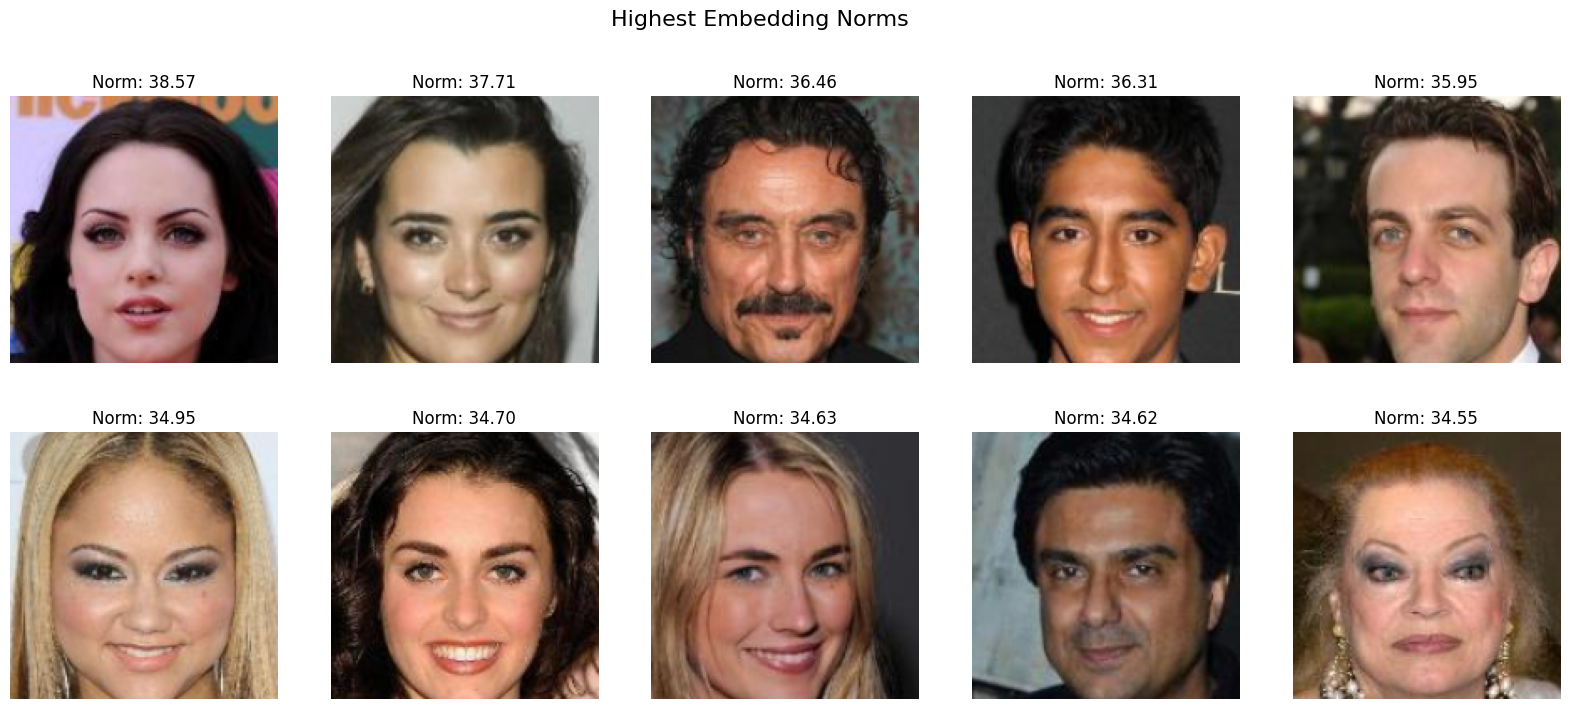

In [39]:
model_arcface.eval()
all_norms = []
all_imgs = []

with torch.no_grad():
    for batch in test_loader:
        imgs = batch['image'].to(device)
        features = model_arcface.backbone(imgs)
        raw_embeddings = model_arcface.projection(features)
        norms = torch.norm(raw_embeddings, p=2, dim=1)
        all_norms.append(norms.cpu())
        all_imgs.append(imgs.cpu())

all_norms = torch.cat(all_norms)
all_imgs = torch.cat(all_imgs)
top_vals, top_indices = torch.sort(all_norms, descending=True)

plt.figure(figsize=(20, 8))
for i in range(10):
    if i >= len(all_imgs): break
    idx = top_indices[i]
    norm_val = top_vals[i].item()
    img = all_imgs[idx].permute(1, 2, 0).numpy()
    img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    img = np.clip(img, 0, 1)
    plt.subplot(2, 5, i + 1)
    plt.imshow(img)
    plt.title(f"Norm: {norm_val:.2f}")
    plt.axis('off')

plt.suptitle("Highest Embedding Norms", fontsize=16)
plt.show()

видно что у них всех немного странное выражение лица, но не сказать что у них есть дефекты